# Project 3

group:
- Ole Lie-Bjelland
- Anniken Marie Lingstad
- Emil Ingar Hals

We did NOT use any AI for this project.

## Topic 1

### Task 0

Our coordnate box will use angstrom units. To ensure that all the points in the dna molecule fit in the box we found the lowest and highest of each x,y,z value in the dna_coords.txt file. The box is then expanded by 5 angstrom in every direction to ensure that the atomic radius of each point remains inside the simulation box

In [2]:
from main import gen_simulation_box

simulation_box = gen_simulation_box(10, 10, 10)
simulation_box_volume = simulation_box.volume()

print(f"Simulation box: {simulation_box}")
print(f"Simulation box volume: {simulation_box_volume}")

Simulation box: 
min x: 0
max x: 10
min y: 0
max y: 10
min z: 0
max z: 10

Simulation box volume: 1000


### Task 1

In [3]:
from main import gen_random_points

point_count = 3
points = gen_random_points(simulation_box, point_count)
print(f"Generated {len(points)} random points:")
for p in points:
    print(p)

Generated 3 random points:
x: 3.5184332051883382
y: 7.8608467232080335
z: 6.781501133127086

x: 2.6681314210579252
y: 5.661025922476704
z: 7.840041615428123

x: 5.249439969331014
y: 1.1118644945533684
z: 9.745011293256496



### Task 2

In [4]:
from main import gen_spheres

spheres = gen_spheres(simulation_box, 1)
for s in spheres:
    print(s)

Sphere radius: 1.0655835620983152
Sphere location:
x: 1.5147649423397602
y: 5.01247146465443
z: 5.088482590001288



### Task 3

In [5]:
from main import point_in_spheres

rand_point = gen_random_points(simulation_box, 1)[0]
print(f"Point: \n{rand_point}")

assert point_in_spheres(spheres, spheres[0].point), "point_in_spheres function not working"   # This should always be true

if point_in_spheres(spheres, rand_point):
    print("The point is in the sphere")
else:
    print("The point is not in the sphere")


Point: 
x: 7.988005459736324
y: 7.760650523811137
z: 1.587983643493175

The point is not in the sphere


### Task 4

We can check the montecarlo simulation result by comparing it to the volume of a sphere given by the formula: $V = \frac{4}{3} \pi r^3$


sphere radius is: 1.2330150332728964
The fraction of points in the sphere is 0.007862
The volume of the simulation box is: 1000
Estimated volume of sphere: 7.861999999999999
Analytical volume of sphere: 7.852242878027161


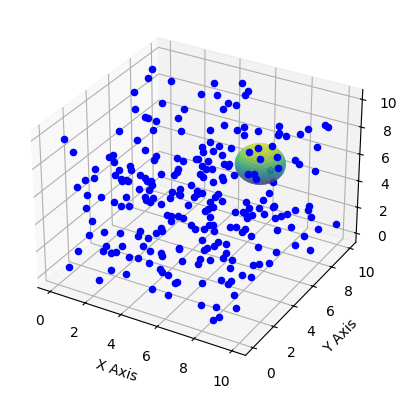

In [6]:
num_of_points = 500000
sphere = gen_spheres(simulation_box, 1)
random_points = gen_random_points(simulation_box, num_of_points)

print(f"sphere radius is: {sphere[0].rad}")

points_in_sphere = 0
for point in random_points:
    if point_in_spheres(sphere, point):
        points_in_sphere += 1

estimated_volume = simulation_box.volume() * (points_in_sphere/num_of_points)

print(f"The fraction of points in the sphere is {points_in_sphere/num_of_points}")
print(f"The volume of the simulation box is: {simulation_box.volume()}")
print(f"Estimated volume of sphere: {estimated_volume}")
print(f"Analytical volume of sphere: {sphere[0].volume()}")

# Plotting
from main import plot_points_and_spheres
plot_points_and_spheres(sphere, random_points[:250])   # Only plotting 250 points because plotting all of them is very slow


### Task 5

$$
V = \frac{4}{3} \pi r^3 \to \pi = \frac{3V}{4 \cdot r^3}
$$

In [7]:
estimated_pi = (estimated_volume*3)/(4*sphere[0].rad**3)
print(f"Estimated pi: {estimated_pi}")

Estimated pi: 3.145496366603539


### Task 6

In [8]:
spheres = gen_spheres(simulation_box, 10)

# Show the first 3 of the 10 new spheres
for s in spheres[:3]:
    print(s)

Sphere radius: 1.0104301374046207
Sphere location:
x: 5.902968400714136
y: 5.97264598830665
z: 4.7765118868048395

Sphere radius: 1.6201289912999768
Sphere location:
x: 1.9567451308122135
y: 3.9567655510664945
z: 6.23401510563856

Sphere radius: 1.3112051413902428
Sphere location:
x: 2.43937003788137
y: 2.732559392393521
z: 5.5151809934509



### Task 7

We can verify the results of the simulation in the same way as in task 4. As we know the radius of all the spheres we can calculate their total volume analytically.

Total volume of simulation box: 1000
The fraction of points in the sphere is 0.11863666666666667
The total volume of the generated spheres is: 118.53
The estimated volume is 118.63666666666667


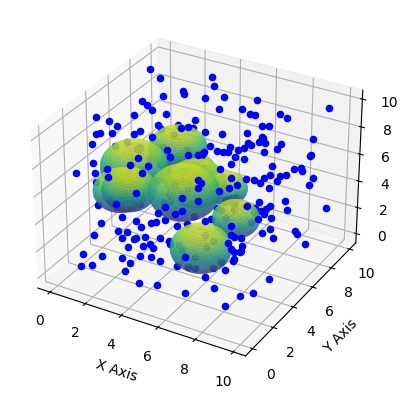

In [9]:
num_of_points = 300000
random_points = gen_random_points(simulation_box, num_of_points)

# Calculate the analytical volume
total_volume = 0
for s in spheres:
    total_volume += s.volume()

points_in_spheres = 0
for point in random_points:
    points_in_spheres += point_in_spheres(spheres, point)

fraction = points_in_spheres/num_of_points
estimated_volume = simulation_box.volume() * fraction
print(f"Total volume of simulation box: {simulation_box.volume()}")
print(f"The fraction of points in the sphere is {fraction}")
print(f"The total volume of the generated spheres is: {round(total_volume, 2)}")
print(f"The estimated volume is {estimated_volume}")

# Plotting
plot_points_and_spheres(spheres, random_points[:250])

### Task 8

In [10]:
from main import get_atoms
atoms = get_atoms()
for a in atoms[:3]:
    print(a)


Atomic symbol: H
Atomic radius: 1.2 angstrom
Position: 
x: -48.18074
y: 1.74518
z: -1.22092



Atomic symbol: O
Atomic radius: 1.52 angstrom
Position: 
x: -48.07374
y: 1.26418
z: -0.40592



Atomic symbol: P
Atomic radius: 1.8 angstrom
Position: 
x: -46.63374
y: 1.27818
z: -0.00492




### Task 9

In [11]:
from main import get_dna_box
dna_box = get_dna_box(atoms)
print("Simulation box for DNA:")
print(dna_box)
print(f"Volume of DNA box: {dna_box.volume()}")

Simulation box for DNA:

min x: -54
max x: -25
min y: -23
max y: 8
min z: -15
max z: 15

Volume of DNA box: 26970


### Task 10

In order to find the analytical volume of the DNA we can use the normal formula for the volume of a sphere as we already know the atomic radius of each atom.

In [12]:
random_point_count = 100000
random_points = gen_random_points(dna_box, random_point_count)

# Check how many of the random points are in the dna
points_in_dna = 0
for p in random_points:
    points_in_dna += point_in_spheres(atoms, p)

fraction = points_in_dna/random_point_count
estimated_dna_volume = dna_box.volume()*fraction

print(f"Volume of simulation box: {dna_box.volume()}")
print(f"Fraction of points in dna: {fraction}")
print(f"Estimated dna volume: {estimated_dna_volume} angstrom^3")


# Analytical approach
import math
analytical_dna_volume = 0
for atom in atoms:
    analytical_dna_volume += math.pi * (4/3) * atom.rad**3

print(f"analytical dna volume: {analytical_dna_volume} angstrom^3")


Volume of simulation box: 26970
Fraction of points in dna: 0.13672
Estimated dna volume: 3687.3384 angstrom^3
analytical dna volume: 3672.2768725392457 angstrom^3


## Topic 2

### Task 1

A simple random walk function without numpy to generate a set of walkers in 3d, starting from different random points. Imported from random_walk.py

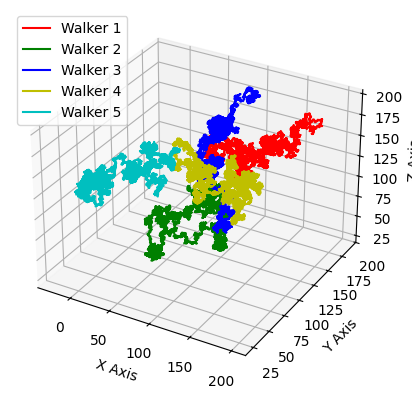

In [13]:
from main import random_walk

random_walk()

### Task 2

The idea is the same as for task 1 but we use numpy this time.

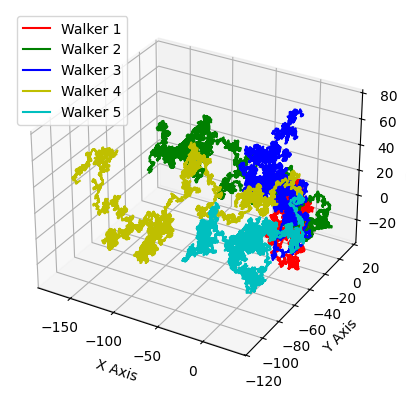

In [14]:
from main import random_walk_fast

random_walk_fast()

### Task 3

We interpret "accessible volume of DNA" as being the surface area of the DNA structure. Our strategy to do this is to:

**First let the walkers walk**
- Divide the 3D space into blocks/cells
- Start a walker in a random block that is not inside an atom
- Let the walker move up, down, left, right, forwards or backwards
- if (new position is inside an atom): save the block and move the walker to a new random block and let it continue walking  
- else: keep walking
- repeat for all walkers


**Then interpret the collected data**
- Check how many uniue blocks were visited by the walkers (remove duplicates)
- Check how many unique surface blocks were discovered
- Calculate how many blocks are in the simulation box
- Calculate the ratio of surface block to non-surface block from the walker data.
- Scale to match the total ammount of points in the simulation box (estimated_surface_blocks = total_blocks * surface_block_fraction)

This approach should work with any shape assuming there is a way to check if any given point is indide the shape or not. More complex shapes would requires smaller block sizes, making this process slow for complex structures.

### Task 4

To verify that this strategy is correct we can test it with a simple shape that has a known surface area, like a sphere. We put the sphere in the simulation box and let the walkers walk round it, hopefully colliding with the sphere which would mark the block as a surface block. We then follow the rest of the steps described in task 3 and compare with the analytical surface area of the sphere.

If it works we can scale up the complexity by adding more spheres to better resemble the DNA structure, if doing this it is important that the test spheres dont overlap as the analytical approach does not take this into consideration.

We will be using this formula to calculate the exact surface area of the test spheres:
$$
A = 4\pi r^2
$$

### Task 5

To ensure that the spheres dont overlap we created an option to run the test with the same 3 spheres every time, to disable this set 'deterministic=False' in the function argument.

Fraction of box covered: 0.9676240000000003
Surface area hits recorded: 662
Actual Surface Area: 115.56215340306483
Estimated Surface Area: 136.83000835035097


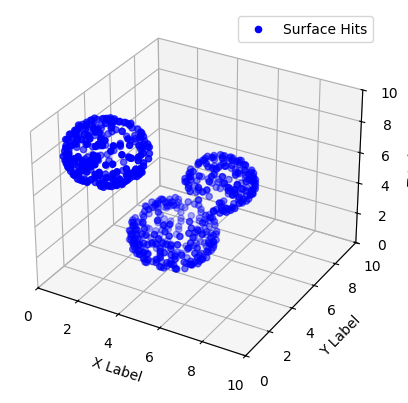

In [15]:
from main import estimate_surface_area

estimate_surface_area(deterministic=True)

# Contributions summary

We divided the project into 3 main parts (topic 1, topic 2, tests), each of us had the main responsibility for one of the three parts. Despite the responsibility assignment we discussed the problems as a group, everyone was involved with the different parts. 

Responsibility distribution: 
- Ole: Topic 1
- Anniken: Topic 2
- Emil: Tests

As stated above we all worked on all three parts and we had an active group chat for finding good solutions. We also engaged in quality checking each others work.

## References

**Topic 1**

- Point class, https://stackoverflow.com/questions/1227121/compare-object-instances-for-equality-by-their-attributes

- point_in_spheres function, https://www.geeksforgeeks.org/python/how-to-get-the-magnitude-of-a-vector-in-numpy/

- plot_points_and_spheres funcction, https://likegeeks.com/3d-sphere-python/

**Topic 2**

- plotting random walk functions, https://stackoverflow.com/questions/11541123/how-can-i-make-a-3d-line-plot